# Sklearn 1:  Data Preprocessing
 Before any model, your data must be clean and ready*


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Make output clean
import warnings
warnings.filterwarnings('ignore')
print("All imports successful")

All imports successful


## 1. Load and Explore Data

The first thing you do with any new dataset is **look at it**. Before any modeling, you need to know:

- **Shape** — how many rows and columns?
- **Types** — which columns are numeric, which are categorical?
- **Missing values** — are there gaps to fill or drop?
- **Distributions** — is anything skewed or has weird outliers?
- **Target balance** (for classification) — is one class dominant?

A few minutes of EDA up front saves hours of debugging mysterious model behavior later.

In [2]:
# Using a built-in sklearn dataset (no download needed)
from sklearn.datasets import load_iris
data = load_iris(as_frame=True)
df = data.frame
df['target_name'] = data.target_names[data.target]

print("Shape:", df.shape)
df.head()

Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# The EDA checklist — run this on every new dataset
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print()
print("=== BASIC STATS ===")
df.describe()

=== DATA TYPES ===
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int32
target_name           object
dtype: object

=== MISSING VALUES ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

=== BASIC STATS ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


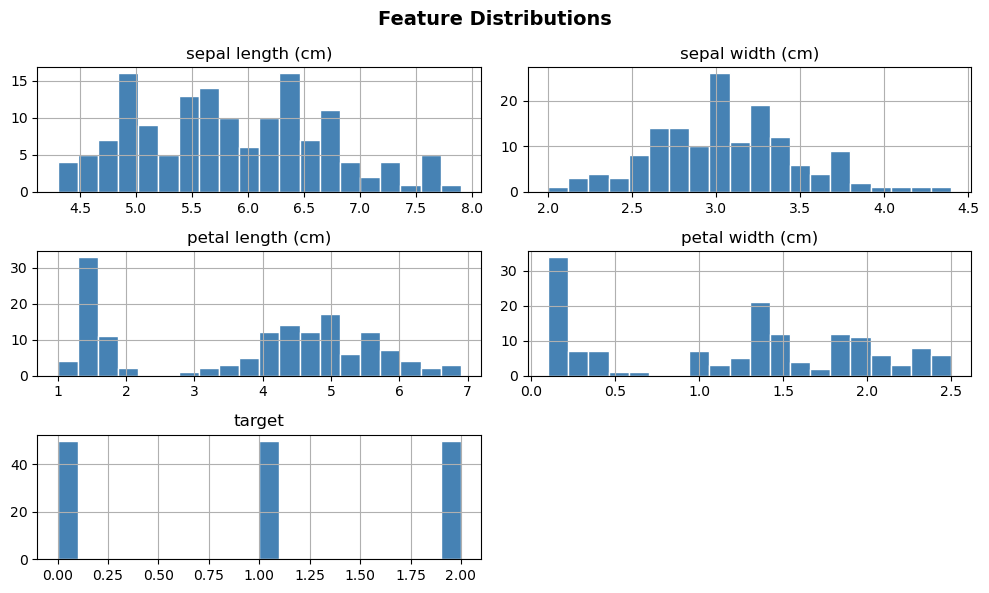

In [4]:
# Visualize distributions
df.hist(figsize=(10, 6), bins=20, color='steelblue', edgecolor='white')
plt.suptitle("Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusions from Feature Distributions:

*   **Sepal Length (cm)**: The distribution appears somewhat bimodal, with noticeable peaks around 5.0 cm and 6.5 cm. This might suggest variations in sepal length across different Iris species.
*   **Sepal Width (cm)**: This feature exhibits a distribution that is relatively bell-shaped, centered between 3.0 cm and 3.5 cm, indicating a more continuous and somewhat normal spread.
*   **Petal Length (cm)**: This distribution is distinctly multimodal, with a prominent peak around 1.0-1.5 cm and another broader peak ranging from approximately 4.0 cm to 5.0 cm. This strong separation is a key indicator of the distinct differences between the Iris species.
*   **Petal Width (cm)**: Similar to petal length, petal width also shows clear multimodal behavior, with a sharp peak around 0.2 cm and a broader peak between 1.2 cm and 1.8 cm. This feature, alongside petal length, is likely very discriminative for species classification.
*   **Target**: The histogram for 'target' (which represents the species) shows three equally sized bars at 0, 1, and 2, indicating that the dataset is balanced with 50 samples for each of the three Iris species.

## 2. Train / Test Split

You split your data into two parts:

- **Training set** (usually 70–80%) — what the model learns from.
- **Test set** (usually 20–30%) — held back to measure how the model does on data it has never seen.

The test set is your stand-in for "real-world data the model will eventually meet." If you let it see the test data during training in any form, the score becomes meaningless.

**Why split FIRST?** If you scale or impute *before* splitting, the statistics used (mean, std) include rows from the test set. That's called **data leakage** — your model has secretly peeked at the answer key, and your test score will look better than it really is. Always split first, then scale only what the training data tells you to.

**Key arguments:**

- `test_size=0.2` — fraction of data held back for testing
- `random_state=42` — locks the random shuffle so results are reproducible
- `stratify=y` — keeps the class proportions equal in both splits (essential for imbalanced classification)

In [5]:
X = df.drop(columns=['target', 'target_name'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # keeps class balance in both splits
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print()
print("Class balance in train:")
print(y_train.value_counts())

Train size: (120, 4)
Test size:  (30, 4)

Class balance in train:
target
0    40
2    40
1    40
Name: count, dtype: int64


## 3. Handling Missing Values

Real-world data has gaps. Three ways to deal with them:

1. **Drop the rows** — fine if missing data is rare (`df.dropna()`).
2. **Drop the column** — if a column is mostly missing, it's often useless.
3. **Impute** — fill in the gaps with a sensible estimate.

`SimpleImputer` is sklearn's tool for option 3. The `strategy=` argument picks the fill value:

| Strategy | Fills missing with | Use when |
|---|---|---|
| `'mean'` | Average of the column | Numeric, roughly symmetric data |
| `'median'` | Middle value | Numeric data with outliers |
| `'most_frequent'` | The most common value | Categorical columns |
| `'constant'` | A fixed value you provide | When you want to mark "missing" explicitly |

Always **fit the imputer on training data only** — same data-leakage logic as scaling.

In [6]:
# Create a dataset with missing values to practice
X_missing = X_train.copy()
np.random.seed(42)
mask = np.random.random(X_missing.shape) < 0.1  # 10% missing
X_missing[mask] = np.nan

print("Missing values before imputation:")
print(X_missing.isnull().sum())

Missing values before imputation:
sepal length (cm)    22
sepal width (cm)     13
petal length (cm)    15
petal width (cm)     13
dtype: int64


In [7]:
# Strategy options: 'mean', 'median', 'most_frequent', 'constant'
imputer = SimpleImputer(strategy='mean')

X_imputed = imputer.fit_transform(X_missing)   # fit_transform on train
X_imputed = pd.DataFrame(X_imputed, columns=X_train.columns)

print("Missing values after imputation:")
print(X_imputed.isnull().sum())
print()
print("Note: imputer.statistics_ = what it learned (the means):")
print(dict(zip(X_train.columns, imputer.statistics_)))

Missing values after imputation:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Note: imputer.statistics_ = what it learned (the means):
{'sepal length (cm)': 5.823469387755103, 'sepal width (cm)': 3.0411214953271024, 'petal length (cm)': 3.831428571428571, 'petal width (cm)': 1.202803738317757}


## 4. Feature Scaling

Imagine two features: `age` (range 0–100) and `salary` (range 0–1,000,000). Without scaling, the salary column dominates anything that computes distances or weighted sums — the age column may as well not exist.

**Scaling** rescales every column so they sit on a similar range. Two common scalers:

| Scaler | Output range | Formula |
|---|---|---|
| **StandardScaler** | Roughly −3 to +3 (mean 0, std 1) | `(x − mean) / std` |
| **MinMaxScaler** | 0 to 1 | `(x − min) / (max − min)` |

**Which models care about scaling?**

- **Need scaling:** linear regression, logistic regression, SVM, KNN, neural networks, k-means.
- **Don't care:** decision trees, random forest, gradient boosting (they only compare values, never sum or weight them).

**The critical rule:** call `fit_transform` on training data, then `transform` (not `fit_transform`) on test data. The scaler should learn the mean and std from the training set only, then apply the same numbers to the test set.

In [8]:
# StandardScaler — mean=0, std=1 (Z-score normalization)
# Use for: LinearRegression, LogisticRegression, SVM, KNN, Neural Nets
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)   # fit ONLY on train
X_test_std  = scaler_std.transform(X_test)         # transform test separately

print("StandardScaler stats learned from TRAIN data:")
print(f"  Mean: {scaler_std.mean_.round(3)}")
print(f"  Std:  {scaler_std.scale_.round(3)}")
print()
print("Before scaling — first 3 rows:")
print(X_train.values[:3])
print()
print("After scaling — first 3 rows:")
print(X_train_std[:3].round(3))

StandardScaler stats learned from TRAIN data:
  Mean: [5.842 3.048 3.77  1.205]
  Std:  [0.837 0.447 1.761 0.759]

Before scaling — first 3 rows:
[[4.4 2.9 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [6.8 2.8 4.8 1.4]]

After scaling — first 3 rows:
[[-1.722 -0.332 -1.346 -1.323]
 [-1.124 -1.228  0.415  0.652]
 [ 1.144 -0.556  0.585  0.257]]


In [9]:
# MinMaxScaler — scales to [0, 1]
# Use for: Neural networks, image data, when you need bounded output
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

print("MinMaxScaler output range:")
print(f"  Min: {X_train_mm.min(axis=0).round(3)}")
print(f"  Max: {X_train_mm.max(axis=0).round(3)}")

MinMaxScaler output range:
  Min: [0. 0. 0. 0.]
  Max: [1. 1. 1. 1.]


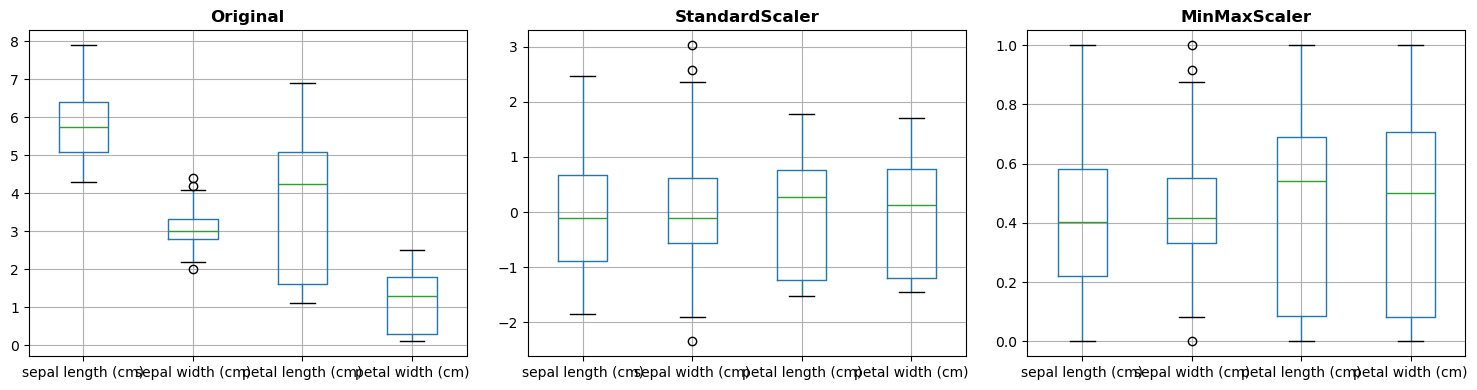

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.DataFrame(X_train).boxplot(ax=axes[0])
axes[0].set_title("Original", fontweight='bold')

pd.DataFrame(X_train_std, columns=X_train.columns).boxplot(ax=axes[1])
axes[1].set_title("StandardScaler", fontweight='bold')

pd.DataFrame(X_train_mm, columns=X_train.columns).boxplot(ax=axes[2])
axes[2].set_title("MinMaxScaler", fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Encoding Categorical Variables

ML models work with numbers, so categorical text columns (city, gender, color) need converting first. Two common approaches:

**Label Encoding** — replace each category with a number: `red → 0, green → 1, blue → 2`. Simple, but the model now thinks `blue > green > red`, which only makes sense for **ordinal** categories (categories with a natural order — small/medium/large, low/medium/high).

**One-Hot Encoding** — create a new binary column for each category. A `color` column becomes three: `is_red`, `is_green`, `is_blue`. No fake ordering — every category is equally distant from every other. Use for **nominal** categories (no order — cities, types, names).

**Which to pick:**

| Category type | Encoding |
|---|---|
| Ordinal (has a natural order) | Label Encoding |
| Nominal (no order) + linear/distance model | One-Hot |
| Nominal + tree-based model | Either works |
| Many unique values (high cardinality) | Avoid one-hot — use target encoding or embeddings instead |

The `drop='first'` argument on `OneHotEncoder` drops one column to avoid the **dummy variable trap** — when all the one-hot columns are perfectly redundant (if `is_red` and `is_green` are both 0, you already know it's blue without `is_blue`). Some models break on this redundancy; safer to drop the first column.

In [11]:
# Create a sample dataset with categorical columns
df_cat = pd.DataFrame({
    'city':   ['Karachi', 'Lahore', 'Karachi', 'Islamabad', 'Lahore'],
    'gender': ['M', 'F', 'M', 'F', 'M'],
    'salary': [50000, 60000, 55000, 70000, 65000]
})
print("Original:")
print(df_cat)

Original:
        city gender  salary
0    Karachi      M   50000
1     Lahore      F   60000
2    Karachi      M   55000
3  Islamabad      F   70000
4     Lahore      M   65000


In [12]:
# Label Encoding — converts to integers
# USE FOR: ordinal categories (small/medium/large) or tree models
le = LabelEncoder()
df_cat['gender_encoded'] = le.fit_transform(df_cat['gender'])
print("Label Encoded gender:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df_cat[['gender', 'gender_encoded']])

Label Encoded gender: {'F': 0, 'M': 1}
  gender  gender_encoded
0      M               1
1      F               0
2      M               1
3      F               0
4      M               1


In [13]:
# One-Hot Encoding — creates binary columns for each category
# USE FOR: nominal categories (no order) with linear/distance-based models
# WARNING: avoid for high-cardinality columns (too many unique values)
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' avoids dummy variable trap
city_encoded = ohe.fit_transform(df_cat[['city']])
city_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out())

print("One-Hot Encoded city:")
print(pd.concat([df_cat['city'], city_df], axis=1))

One-Hot Encoded city:
        city  city_Karachi  city_Lahore
0    Karachi           1.0          0.0
1     Lahore           0.0          1.0
2    Karachi           1.0          0.0
3  Islamabad           0.0          0.0
4     Lahore           0.0          1.0


In [14]:
# pandas get_dummies — quick alternative for notebooks
print("pd.get_dummies (quick and clean):")
print(pd.get_dummies(df_cat['city'], prefix='city', drop_first=True))

pd.get_dummies (quick and clean):
   city_Karachi  city_Lahore
0          True        False
1         False         True
2          True        False
3         False        False
4         False         True


## 6. Sklearn Pipelines — Chain Everything Together

By now you've seen the pattern: fit something on train, transform both sets, then fit a model. Doing this by hand is error-prone — it's easy to accidentally `fit_transform` the test set, leak data, or forget a step.

A **`Pipeline`** packages all those steps into one object. You give it a list of `(name, transformer)` pairs. When you call `pipe.fit(X_train, y_train)`, sklearn:

1. Fits the first transformer on the training data and transforms it.
2. Passes the result to the next transformer, fits and transforms it.
3. Continues until the final step (the model), which gets `fit()` called.

When you later call `pipe.predict(X_test)` or `pipe.score(X_test, y_test)`, sklearn automatically `transform()`s the test data through each step using what the pipeline learned from training — no leakage, no manual bookkeeping.

**Benefits:**

- One object to save and load — no scattered scalers and encoders to keep track of.
- Cleaner code — the whole preprocessing-plus-model logic in one place.
- Works correctly with `cross_val_score` and `GridSearchCV` out of the box.
- No accidental data leakage.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Chain: scale => model
# fit() on train, predict() on test — scaler is applied correctly automatically
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42))
])

pipe.fit(X_train, y_train)
print(f"Pipeline accuracy: {pipe.score(X_test, y_test):.3f}")
print()
print("Pipeline steps:", [step[0] for step in pipe.steps])

Pipeline accuracy: 0.933

Pipeline steps: ['scaler', 'model']


## Key Takeaways

- Always **split first**, then scale — never the other way around
- **fit_transform** on train, **transform only** on test
- **StandardScaler** for most models, **MinMaxScaler** for neural nets
- **Label Encoding** for ordinal or tree models, **One-Hot** for nominal + linear models
- **Pipelines** = cleaner code + zero leakage
- **Impute** before scaling, always